# Spectra and lightcurve visualization for Early TDE paper

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib widget

In [15]:
#photometry visualization_functions, mostly written by Claude

#photometry visualization_functions, mostly written by Claude


from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------------
# Per-filter styling. Colours follow the usual ZTF / ATLAS / Swift-UVOT
# conventions. Unknown filters fall back to a rotating colour cycle.
# ---------------------------------------------------------------------------
FILTER_STYLE = {
    # ZTF
    "ztfg":       {"color": "#4daf4a", "marker": "o", "label": "ZTF g"},
    "ztfr":       {"color": "#e41a1c", "marker": "o", "label": "ZTF r"},
    "ztfi":       {"color": "#d2a106", "marker": "o", "label": "ZTF i"},
    # ATLAS
    "atlasc":     {"color": "#00c2d1", "marker": "s", "label": "ATLAS c"},
    "atlaso":     {"color": "#ff7f00", "marker": "s", "label": "ATLAS o"},
    # SDSS-like
    "sdssr":      {"color": "#b2182b", "marker": "D", "label": "SDSS r"},
    # Swift UVOT
    "uvot::u":    {"color": "#984ea3", "marker": "^", "label": "UVOT u"},
    "uvot::uvw1": {"color": "#7570b3", "marker": "^", "label": "UVOT uvw1"},
    "uvot::uvm2": {"color": "#54278f", "marker": "^", "label": "UVOT uvm2"},
    "uvot::uvw2": {"color": "#3f007d", "marker": "^", "label": "UVOT uvw2"},
}

_FALLBACK_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def _style_for(filt, i):
    """Return a style dict for a filter, inventing one if it's unknown."""
    if filt in FILTER_STYLE:
        return FILTER_STYLE[filt]
    return {
        "color": _FALLBACK_COLORS[i % len(_FALLBACK_COLORS)],
        "marker": "o",
        "label": str(filt),
    }


def load_photometry(source) -> pd.DataFrame:
    """Load photometry from a CSV path or pass through a DataFrame, cleaning it.

    Coerces numeric columns and drops any junk rows (e.g. a duplicate header
    accidentally embedded in the data).
    """
    df = source.copy() if isinstance(source, pd.DataFrame) else pd.read_csv(source)

    for col in ("mjd", "mag", "magerr", "limiting_mag", "flux", "fluxerr"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # A valid epoch needs a time; this also removes stray header rows.
    df = df.dropna(subset=["mjd"]).reset_index(drop=True)
    return df


def _apply_exclusions(df, exclude_instruments, exclude_filters):
    """Drop rows whose instrument_name or filter is in the exclusion lists.

    Matching is case-insensitive so "ATLAS", "atlas", "Atlas" all work.
    """
    if exclude_instruments and "instrument_name" in df.columns:
        excl = {s.lower() for s in exclude_instruments}
        keep = ~df["instrument_name"].astype(str).str.lower().isin(excl)
        df = df[keep]
    if exclude_filters and "filter" in df.columns:
        exclf = {s.lower() for s in exclude_filters}
        keep = ~df["filter"].astype(str).str.lower().isin(exclf)
        df = df[keep]
    return df.reset_index(drop=True)


def plot_lightcurve(
    source,
    space: str = "mag",
    show_limits: bool = True,
    time_ref: float | str | None = None,
    filters: list[str] | None = None,
    exclude_instruments: list[str] | None = None,
    exclude_filters: list[str] | None = None,
    title: str | None = None,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] = (11, 6),
):
    """Plot a multi-band light curve.

    Parameters
    ----------
    source
        Path to a CSV file or a pandas DataFrame with the expected columns.
    space : {"mag", "flux"}
        Plot magnitudes (y-axis inverted) or flux (linear, not inverted).
    show_limits : bool
        If True and plotting in mag space, draw non-detections as downward
        upper-limit triangles at `limiting_mag`. Set False to hide all upper
        limits and show detections only.
    time_ref : float | "first" | "peak" | None
        Reference epoch subtracted from MJD for the x-axis.
        - None  -> plot raw MJD
        - float -> subtract that MJD
        - "first" -> subtract the first detection's MJD
        - "peak"  -> subtract the brightest detection's MJD
    filters : list[str] | None
        Restrict to these filters (in this legend order). Default: all present,
        ordered by first appearance.
    exclude_instruments : list[str] | None
        Instrument names (from `instrument_name`) to drop entirely, both
        detections and limits. Case-insensitive. e.g. ["ATLAS"] skips ATLAS.
    exclude_filters : list[str] | None
        Filter names to drop entirely. Case-insensitive. e.g. ["atlasc",
        "atlaso"] drops just the two ATLAS bands, or ["ztfi"] drops ZTF i.
    title : str | None
        Plot title.
    ax : matplotlib Axes | None
        Draw into an existing Axes; otherwise a new figure is created.
    figsize : (w, h)
        Figure size when a new figure is created.

    Returns
    -------
    (fig, ax)
    """
    if space not in ("mag", "flux"):
        raise ValueError("space must be 'mag' or 'flux'")

    df = load_photometry(source)
    df = _apply_exclusions(df, exclude_instruments, exclude_filters)
    if df.empty:
        raise ValueError("No photometry left to plot after exclusions.")

    is_det = df["mag"].notna() if space == "mag" else df["flux"].notna()

    # ----- work out the time reference -----------------------------------
    offset, xlabel = 0.0, "MJD"
    dets = df[df["mag"].notna()]
    if time_ref == "first":
        if not dets.empty:
            offset = dets["mjd"].min()
            xlabel = f"Days since first detection (MJD {offset:.2f})"
    elif time_ref == "peak":
        if not dets.empty:
            offset = dets.loc[dets["mag"].idxmin(), "mjd"]  # min mag = brightest
            xlabel = f"Days since peak (MJD {offset:.2f})"
    elif isinstance(time_ref, (int, float)):
        offset = float(time_ref)
        xlabel = f"MJD - {offset:.2f}"
    t = df["mjd"] - offset

    # ----- filter order --------------------------------------------------
    if filters is None:
        filters = list(dict.fromkeys(df["filter"].dropna()))

    # ----- set up axes ---------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for i, filt in enumerate(filters):
        style = _style_for(filt, i)
        sel = df["filter"] == filt

        det = sel & is_det
        lim = sel & ~is_det

        if space == "mag":
            # detections with error bars
            if det.any():
                ax.errorbar(
                    t[det], df.loc[det, "mag"], yerr=df.loc[det, "magerr"],
                    fmt=style["marker"], color=style["color"], mec="k", mew=0.4,
                    ms=6, elinewidth=1, capsize=0, linestyle="none",
                    alpha=0.9, zorder=3,
                )
            # non-detections as upper-limit triangles
            if show_limits and lim.any():
                ax.scatter(
                    t[lim], df.loc[lim, "limiting_mag"],
                    marker="v", facecolors="none", edgecolors=style["color"],
                    s=32, linewidths=0.8, alpha=0.35, zorder=1,
                )
        else:  # flux space
            if det.any():
                ax.errorbar(
                    t[det], df.loc[det, "flux"], yerr=df.loc[det, "fluxerr"],
                    fmt=style["marker"], color=style["color"], mec="k", mew=0.4,
                    ms=6, elinewidth=1, capsize=0, linestyle="none",
                    alpha=0.9, zorder=3,
                )

    # ----- legend (only for filters that actually plotted) ---------------
    handles = []
    for i, filt in enumerate(filters):
        if not (df["filter"] == filt).any():
            continue
        style = _style_for(filt, i)
        handles.append(
            Line2D([0], [0], marker=style["marker"], color="none",
                   markerfacecolor=style["color"], markeredgecolor="k",
                   markeredgewidth=0.4, markersize=7, label=style["label"])
        )
    if show_limits and space == "mag":
        handles.append(
            Line2D([0], [0], marker="v", color="none", markerfacecolor="none",
                   markeredgecolor="gray", markersize=7, label="upper limit")
        )

    ax.legend(handles=handles, ncol=2, frameon=True, fontsize=9,
              loc="best", framealpha=0.9)

    # ----- labels / axis direction --------------------------------------
    ax.set_xlabel(xlabel)
    if space == "mag":
        ax.set_ylabel("Apparent magnitude")
        if not ax.yaxis_inverted():
            ax.invert_yaxis()
    else:
        ax.set_ylabel("Flux (µJy)")

    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    return fig, ax


# from __future__ import annotations

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D


# ---------------------------------------------------------------------------
# Per-filter styling. Colours follow the usual ZTF / ATLAS / Swift-UVOT
# conventions. Unknown filters fall back to a rotating colour cycle.
# ---------------------------------------------------------------------------
# FILTER_STYLE = {
#     # ZTF
#     "ztfg":       {"color": "#4daf4a", "marker": "o", "label": "ZTF g"},
#     "ztfr":       {"color": "#e41a1c", "marker": "o", "label": "ZTF r"},
#     "ztfi":       {"color": "#d2a106", "marker": "o", "label": "ZTF i"},
#     # ATLAS
#     "atlasc":     {"color": "#00c2d1", "marker": "s", "label": "ATLAS c"},
#     "atlaso":     {"color": "#ff7f00", "marker": "s", "label": "ATLAS o"},
#     # SDSS-like
#     "sdssr":      {"color": "#b2182b", "marker": "D", "label": "SDSS r"},
#     # Swift UVOT
#     "uvot::u":    {"color": "#984ea3", "marker": "^", "label": "UVOT u"},
#     "uvot::uvw1": {"color": "#7570b3", "marker": "^", "label": "UVOT uvw1"},
#     "uvot::uvm2": {"color": "#54278f", "marker": "^", "label": "UVOT uvm2"},
#     "uvot::uvw2": {"color": "#3f007d", "marker": "^", "label": "UVOT uvw2"},
# }

# _FALLBACK_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# def _style_for(filt, i):
#     """Return a style dict for a filter, inventing one if it's unknown."""
#     if filt in FILTER_STYLE:
#         return FILTER_STYLE[filt]
#     return {
#         "color": _FALLBACK_COLORS[i % len(_FALLBACK_COLORS)],
#         "marker": "o",
#         "label": str(filt),
#     }


# def load_photometry(source) -> pd.DataFrame:
#     """Load photometry from a CSV path or pass through a DataFrame, cleaning it.

#     Coerces numeric columns and drops any junk rows (e.g. a duplicate header
#     accidentally embedded in the data).
#     """
#     df = source.copy() if isinstance(source, pd.DataFrame) else pd.read_csv(source)

#     for col in ("mjd", "mag", "magerr", "limiting_mag", "flux", "fluxerr"):
#         if col in df.columns:
#             df[col] = pd.to_numeric(df[col], errors="coerce")

#     # A valid epoch needs a time; this also removes stray header rows.
#     df = df.dropna(subset=["mjd"]).reset_index(drop=True)
#     return df


# def plot_lightcurve(
#     source,
#     space: str = "mag",
#     show_limits: bool = True,
#     time_ref: float | str | None = None,
#     filters: list[str] | None = None,
#     title: str | None = None,
#     ax: plt.Axes | None = None,
#     figsize: tuple[float, float] = (11, 6),
# ):
#     """Plot a multi-band light curve.

#     Parameters
#     ----------
#     source
#         Path to a CSV file or a pandas DataFrame with the expected columns.
#     space : {"mag", "flux"}
#         Plot magnitudes (y-axis inverted) or flux (linear, not inverted).
#     show_limits : bool
#         If True and plotting in mag space, draw non-detections as downward
#         upper-limit triangles at `limiting_mag`.
#     time_ref : float | "first" | "peak" | None
#         Reference epoch subtracted from MJD for the x-axis.
#         - None  -> plot raw MJD
#         - float -> subtract that MJD
#         - "first" -> subtract the first detection's MJD
    #     - "peak"  -> subtract the brightest detection's MJD
    # filters : list[str] | None
    #     Restrict to these filters (in this legend order). Default: all present,
    #     ordered by first appearance.
    # title : str | None
    #     Plot title.
    # ax : matplotlib Axes | None
    #     Draw into an existing Axes; otherwise a new figure is created.
    # figsize : (w, h)
    #     Figure size when a new figure is created.

    # Returns
    # -------
    # (fig, ax)
    # """
    # if space not in ("mag", "flux"):
    #     raise ValueError("space must be 'mag' or 'flux'")

    # df = load_photometry(source)
    # is_det = df["mag"].notna() if space == "mag" else df["flux"].notna()

    # # ----- work out the time reference -----------------------------------
    # offset, xlabel = 0.0, "MJD"
    # dets = df[df["mag"].notna()]
    # if time_ref == "first":
    #     if not dets.empty:
    #         offset = dets["mjd"].min()
    #         xlabel = f"Days since first detection (MJD {offset:.2f})"
    # elif time_ref == "peak":
    #     if not dets.empty:
    #         offset = dets.loc[dets["mag"].idxmin(), "mjd"]  # min mag = brightest
    #         xlabel = f"Days since peak (MJD {offset:.2f})"
    # elif isinstance(time_ref, (int, float)):
    #     offset = float(time_ref)
    #     xlabel = f"MJD - {offset:.2f}"
    # t = df["mjd"] - offset

    # # ----- filter order --------------------------------------------------
    # if filters is None:
    #     filters = list(dict.fromkeys(df["filter"].dropna()))

    # # ----- set up axes ---------------------------------------------------
    # if ax is None:
    #     fig, ax = plt.subplots(figsize=figsize)
    # else:
    #     fig = ax.figure

    # for i, filt in enumerate(filters):
    #     style = _style_for(filt, i)
    #     sel = df["filter"] == filt

    #     det = sel & is_det
    #     lim = sel & ~is_det

    #     if space == "mag":
    #         # detections with error bars
    #         if det.any():
    #             ax.errorbar(
    #                 t[det], df.loc[det, "mag"], yerr=df.loc[det, "magerr"],
    #                 fmt=style["marker"], color=style["color"], mec="k", mew=0.4,
    #                 ms=6, elinewidth=1, capsize=0, linestyle="none",
    #                 alpha=0.9, zorder=3,
    #             )
    #         # non-detections as upper-limit triangles
    #         if show_limits and lim.any():
    #             ax.scatter(
    #                 t[lim], df.loc[lim, "limiting_mag"],
    #                 marker="v", facecolors="none", edgecolors=style["color"],
    #                 s=32, linewidths=0.8, alpha=0.35, zorder=1,
    #             )
    #     else:  # flux space
    #         if det.any():
    #             ax.errorbar(
    #                 t[det], df.loc[det, "flux"], yerr=df.loc[det, "fluxerr"],
    #                 fmt=style["marker"], color=style["color"], mec="k", mew=0.4,
    #                 ms=6, elinewidth=1, capsize=0, linestyle="none",
    #                 alpha=0.9, zorder=3,
    #             )

    # # ----- legend (only for filters that actually plotted) ---------------
    # handles = []
    # for i, filt in enumerate(filters):
    #     if not (df["filter"] == filt).any():
    #         continue
    #     style = _style_for(filt, i)
    #     handles.append(
    #         Line2D([0], [0], marker=style["marker"], color="none",
    #                markerfacecolor=style["color"], markeredgecolor="k",
    #                markeredgewidth=0.4, markersize=7, label=style["label"])
    #     )
    # if show_limits and space == "mag":
    #     handles.append(
    #         Line2D([0], [0], marker="v", color="none", markerfacecolor="none",
    #                markeredgecolor="gray", markersize=7, label="upper limit")
    #     )

    # ax.legend(handles=handles, ncol=2, frameon=True, fontsize=9,
    #           loc="best", framealpha=0.9)

    # # ----- labels / axis direction --------------------------------------
    # ax.set_xlabel(xlabel)
    # if space == "mag":
    #     ax.set_ylabel("Apparent magnitude")
    #     if not ax.yaxis_inverted():
    #         ax.invert_yaxis()
    # else:
    #     ax.set_ylabel("Flux (µJy)")

    # if title:
    #     ax.set_title(title)
    # ax.grid(True, alpha=0.2)
    # fig.tight_layout()
    # return fig, ax


In [16]:
# spectra visualizaiton functions, also written by Claude

"""
Stacked multi-epoch spectral sequence plotting.

Reads spectra from files named  {spectrograph}_{date}.{ext}  where date looks
like  2024-05-16T10-26-23  (ISO, with ':' -> '-' in the time so it's filename
safe). All formats are two-column  wavelength,flux  (a header line is allowed);
this covers the .flm and .txt files used here.

Because different spectrographs deliver fluxes on totally different scales
(physical erg/s/cm^2/A vs. arbitrary counts), each spectrum is normalized before
stacking. Spectra are offset vertically and labelled with the phase relative to
either the first spectrum or a supplied peak date.

Example
-------
    from plot_spectra import plot_spectra
    fig, ax = plot_spectra("*.flm", extra="*.txt", peak_date="2024-05-11",
                           smooth=5, title="ZTF24aakaiha")
"""

from __future__ import annotations

import os
import re
import glob
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize


# ---------------------------------------------------------------------------
# Filename / date parsing
# ---------------------------------------------------------------------------
_DATE_FORMATS = ("%Y-%m-%dT%H-%M-%S", "%Y-%m-%dT%H:%M:%S",
                 "%Y-%m-%d", "%Y%m%d")


def _parse_date(s: str) -> datetime:
    s = s.strip()
    try:
        return datetime.fromisoformat(s)
    except ValueError:
        pass
    for fmt in _DATE_FORMATS:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    raise ValueError(f"Could not parse a date from {s!r}")


def parse_spec_filename(path: str):
    """From '.../sedm_2024-05-11T06-30-05.txt' -> ('sedm', datetime(...))."""
    stem = os.path.splitext(os.path.basename(path))[0]
    m = re.match(r"(?P<inst>.+?)_(?P<date>\d{4}-\d{2}-\d{2}.*)$", stem)
    if not m:
        raise ValueError(f"Filename {stem!r} is not '{{instrument}}_{{date}}'")
    return m.group("inst"), _parse_date(m.group("date"))


# ---------------------------------------------------------------------------
# I/O and normalization
# ---------------------------------------------------------------------------
def load_spectrum(path: str) -> pd.DataFrame:
    """Read a two-column wavelength,flux file (header optional)."""
    df = pd.read_csv(path)
    # If there was no header, columns come in as numbers -> reload headerless.
    if df.shape[1] < 2 or not {"wavelength", "flux"} <= set(
        c.lower() for c in df.columns.astype(str)
    ):
        df = pd.read_csv(path, header=None, names=["wavelength", "flux"])
    df.columns = [c.lower() for c in df.columns.astype(str)]
    df = df.rename(columns={df.columns[0]: "wavelength", df.columns[1]: "flux"})
    for c in ("wavelength", "flux"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(subset=["wavelength", "flux"]).sort_values("wavelength")


def _normalize(flux: np.ndarray, method):
    """Put heterogeneous fluxes onto a comparable vertical scale."""
    f = np.asarray(flux, float)
    if method is None:
        return f
    if method == "median":                         # continuum -> ~1
        s = np.nanmedian(f)
        if not np.isfinite(s) or abs(s) < 1e-3 * (np.nanstd(f) or 1):
            s = np.nanstd(f) or 1.0
        return f / s
    if method == "max":                            # peak -> ~1
        s = np.nanpercentile(f, 99) or 1.0
        return f / s
    if method in ("robust", "standard"):           # median->0, spread->~1
        med = np.nanmedian(f)
        lo, hi = np.nanpercentile(f, [16, 84])
        scale = (hi - lo) or (np.nanstd(f) or 1.0)
        return (f - med) / scale
    if method == "range":                          # ~0..1
        lo, hi = np.nanpercentile(f, [2, 98])
        return (f - lo) / ((hi - lo) or 1.0)
    raise ValueError(f"unknown normalize={method!r}")


def _smooth(flux: np.ndarray, window: int):
    """Simple odd-length boxcar smoothing for display."""
    if not window or window < 2:
        return flux
    window = int(window) | 1                        # force odd
    kern = np.ones(window) / window
    return np.convolve(flux, kern, mode="same")


# ---------------------------------------------------------------------------
# Main plot
# ---------------------------------------------------------------------------
def plot_spectra(
    sources,
    extra=None,
    peak_date=None,
    normalize: str | None = "median",
    offset: float | None = None,
    smooth: int | None = None,
    redshift: float | None = None,
    wave_range: tuple[float, float] | None = None,
    ascending: bool = True,
    cmap: str = "plasma",
    phase_unit: str = "d",
    title: str | None = None,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] | None = None,
):
    """Plot a vertically-offset stack of spectra ordered by epoch.

    Parameters
    ----------
    sources, extra
        File paths, glob patterns, or lists thereof. `extra` is a convenience
        second bucket so you can mix formats, e.g. sources="*.flm", extra="*.txt".
    peak_date : str | datetime | None
        Reference epoch for the phase labels. If None, the earliest spectrum is
        used as phase 0 and labels read "+N.N d".
    normalize : {"median","max","robust","range",None}
        How to rescale each spectrum before stacking. "median" (continuum ~1) is
        the default; "robust" (median->0, IQR->1) is better for noisy spectra.
    offset : float | None
        Vertical step between spectra in normalized units. None -> auto.
    smooth : int | None
        Odd boxcar window (in pixels) for display smoothing. Helpful for SEDM.
    redshift : float | None
        If given, wavelengths are divided by (1+z) and the axis is labelled rest.
    wave_range : (min,max) | None
        Trim each spectrum to this observed-wavelength window before plotting.
    ascending : bool
        True -> earliest spectrum at the top (time increases downward).
    cmap : str
        Matplotlib colormap used to colour spectra by phase.
    phase_unit : "d"
        Label suffix for the phase; only days are computed here.

    Returns
    -------
    (fig, ax)
    """
    # ---- gather files ----------------------------------------------------
    def _expand(x):
        if x is None:
            return []
        if isinstance(x, (list, tuple)):
            out = []
            for item in x:
                out.extend(_expand(item))
            return out
        return sorted(glob.glob(x)) if any(ch in x for ch in "*?[") else [x]

    paths = _expand(sources) + _expand(extra)
    if not paths:
        raise ValueError("No spectra found for the given sources.")

    # ---- load + parse epochs --------------------------------------------
    specs = []
    for p in paths:
        inst, when = parse_spec_filename(p)
        specs.append({"path": p, "inst": inst, "when": when,
                      "df": load_spectrum(p)})

    ref = _parse_date(peak_date) if isinstance(peak_date, str) else peak_date
    if ref is None:
        ref = min(s["when"] for s in specs)
        phase_label = "since first spectrum"
    else:
        phase_label = "since peak"
    for s in specs:
        s["phase"] = (s["when"] - ref).total_seconds() / 86400.0

    specs.sort(key=lambda s: s["phase"])            # earliest first

    # ---- normalize / smooth / trim; record spreads for auto offset ------
    spreads = []
    for s in specs:
        df = s["df"]
        w = df["wavelength"].to_numpy()
        f = df["flux"].to_numpy()
        if redshift:
            w = w / (1.0 + redshift)
        if wave_range:
            m = (w >= wave_range[0]) & (w <= wave_range[1])
            w, f = w[m], f[m]
        f = _normalize(f, normalize)
        f = _smooth(f, smooth)
        s["w"], s["f"] = w, f
        lo, hi = np.nanpercentile(f, [5, 95])
        spreads.append(hi - lo)

    if offset is None:
        offset = 1.25 * float(np.nanmedian(spreads))
        if not np.isfinite(offset) or offset <= 0:
            offset = 1.0

    # ---- colours by phase ------------------------------------------------
    phases = np.array([s["phase"] for s in specs])
    pmin, pmax = float(phases.min()), float(phases.max())
    norm = Normalize(vmin=pmin, vmax=(pmax if pmax > pmin else pmin + 1))
    colormap = cm.get_cmap(cmap)

    n = len(specs)
    if figsize is None:
        figsize = (9.5, 2.2 + 1.15 * n)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # ---- draw ------------------------------------------------------------
    for i, s in enumerate(specs):
        level = (n - 1 - i) if ascending else i     # earliest at top
        y = s["f"] + level * offset
        color = colormap(norm(s["phase"]))
        ax.plot(s["w"], y, lw=0.8, color=color, solid_capstyle="round")

        sign = "+" if s["phase"] >= 0 else "\u2212"
        lbl = f"{s['inst']}   {sign}{abs(s['phase']):.1f} {phase_unit}"
        ax.text(
            s["w"].max(), level * offset + np.nanmedian(s["f"]),
            "  " + lbl, va="center", ha="left", fontsize=9, color=color,
            clip_on=False,
        )

    # ---- cosmetics -------------------------------------------------------
    xlabel = ("Rest wavelength" if redshift else "Observed wavelength") + r" [$\AA$]"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Scaled $F_\lambda$ + offset")
    ax.set_yticks([])
    # give the right-hand labels room
    x0 = min(s["w"].min() for s in specs)
    x1 = max(s["w"].max() for s in specs)
    ax.set_xlim(x0 - 0.01 * (x1 - x0), x1 + 0.18 * (x1 - x0))
    if title:
        ax.set_title(title)
    ax.margins(y=0.02)

    sm = cm.ScalarMappable(norm=norm, cmap=colormap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, fraction=0.03)
    cbar.set_label(f"Phase {phase_label} [{phase_unit}]")

    fig.tight_layout()
    return fig, ax



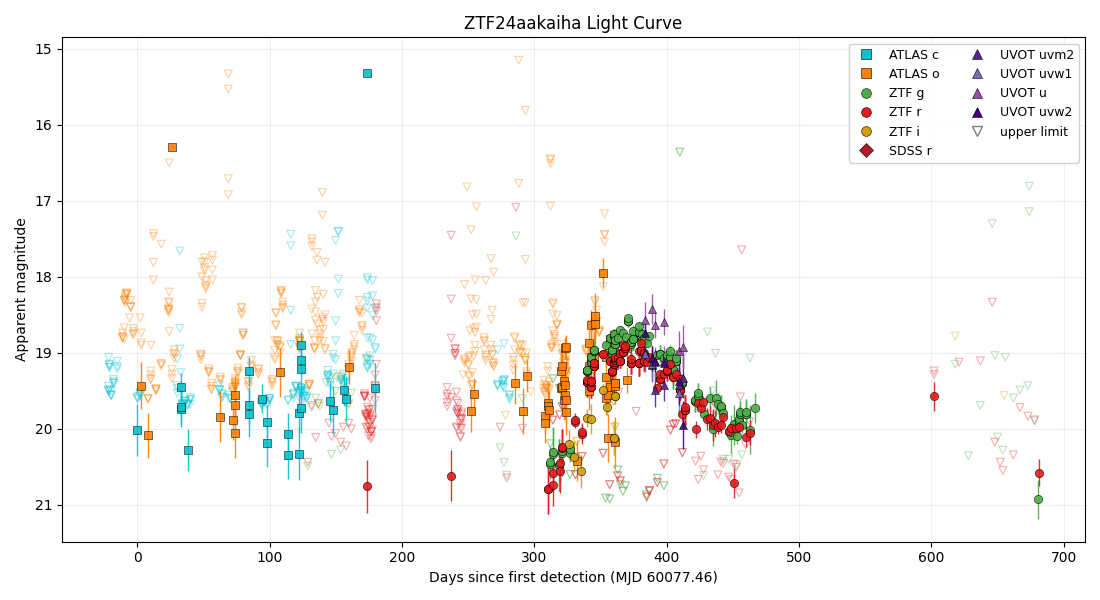

In [17]:
# ZTF24aakaiha

ZTF24aakaiha_path = "/Users/jon/Research/ATALab/Early_TDE_paper/observations/ZTF24aakaiha"
csv_path = Path(f"{ZTF24aakaiha_path}/ZTF24aakaiha_photometry.csv")

#plot the lightcurve
fig, ax = plot_lightcurve(csv_path, space="mag", time_ref="first", title="ZTF24aakaiha Light Curve")



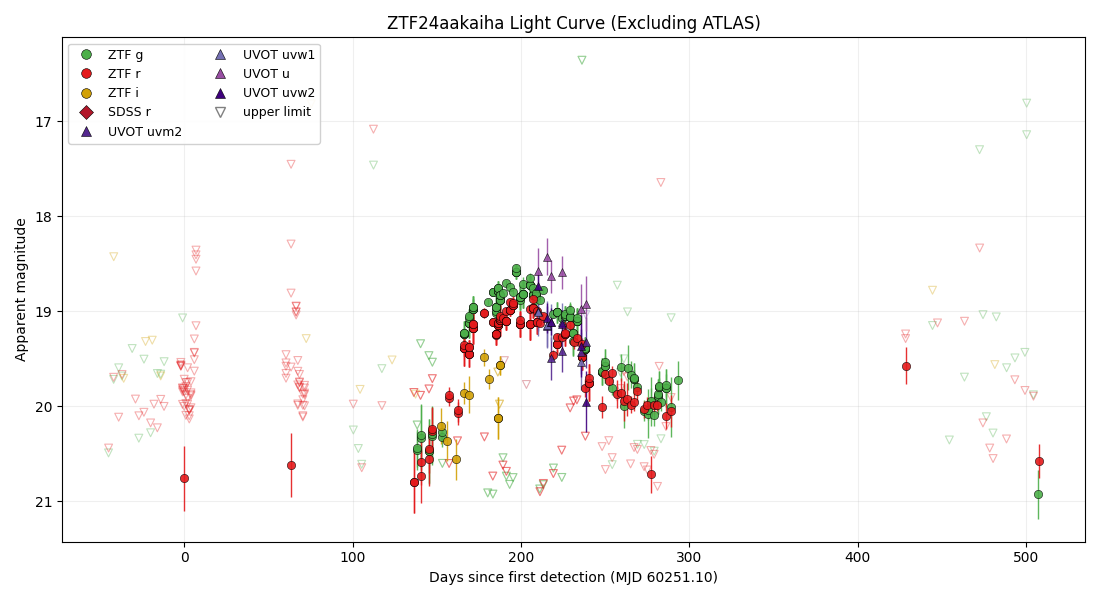

In [19]:
#testing again with exlusions
fig, ax = plot_lightcurve(csv_path, space="mag", time_ref="first", title="ZTF24aakaiha Light Curve (Excluding ATLAS)", exclude_instruments=["ATLAS"])

/var/folders/k3/l6fjnjt51mv03h22m9cpmzgw0000gn/T/ipykernel_66264/3536058357.py:228: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


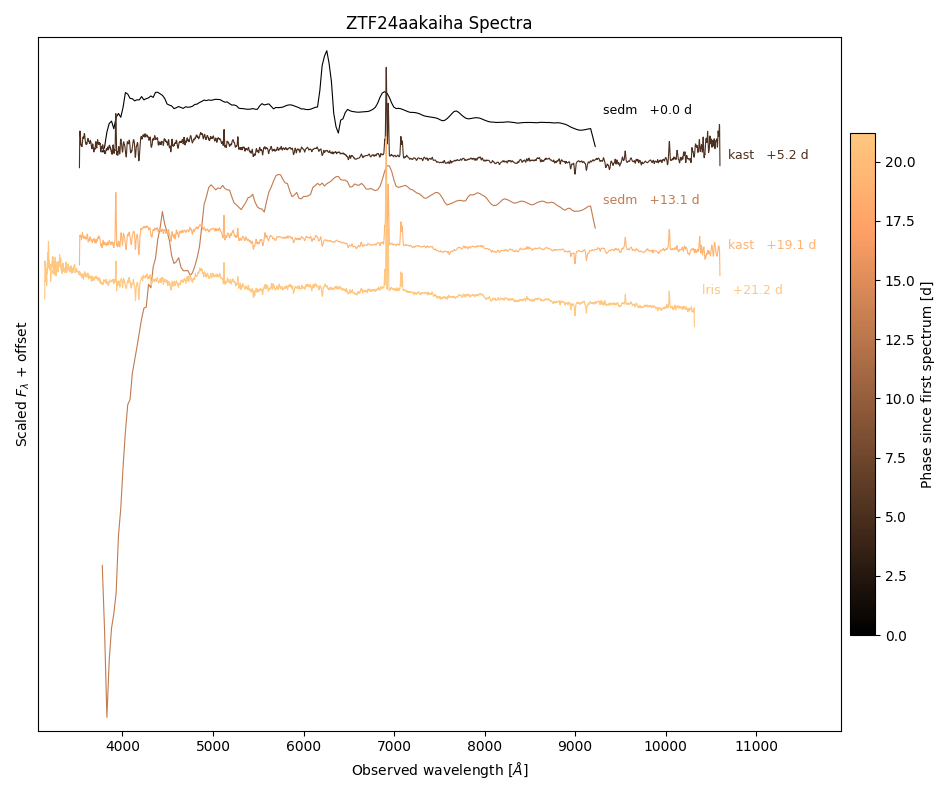

In [14]:
# now for the spectra of ZTF24aakaiha

import glob

spectra_paths = glob.glob(f"{ZTF24aakaiha_path}/*.flm") + glob.glob(f"{ZTF24aakaiha_path}/*.txt")

#plot the spectra
fig, ax = plot_spectra(spectra_paths, peak_date=None, normalize="median", smooth=5, title="ZTF24aakaiha Spectra", cmap="copper")

# ZTF24abmybnp

/var/folders/k3/l6fjnjt51mv03h22m9cpmzgw0000gn/T/ipykernel_66264/1381080852.py:228: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


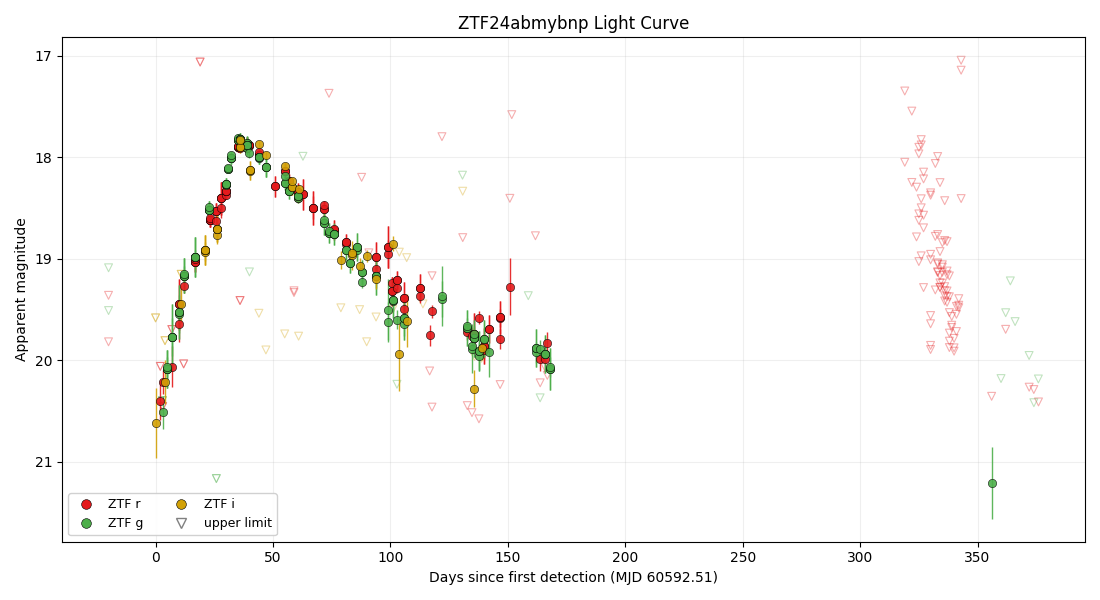

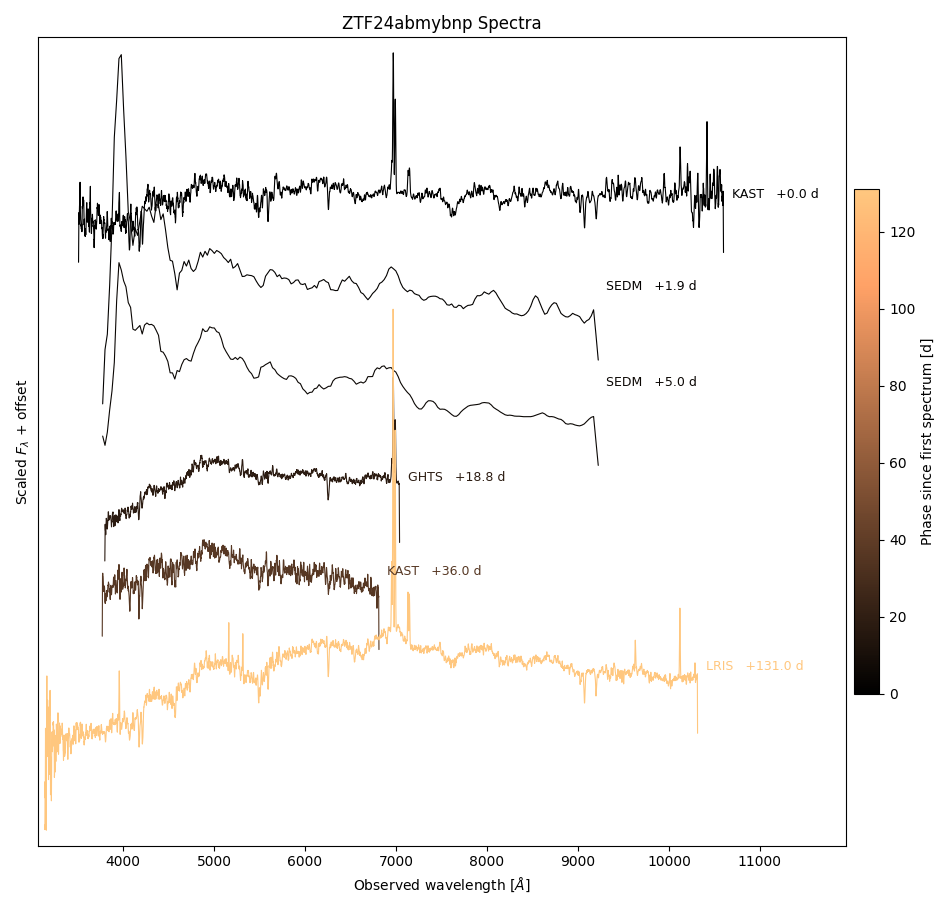

In [21]:
# now let's test for ZTF24abmybnp
ZTF24abmybnp_path = "/Users/jon/Research/ATALab/Early_TDE_paper/observations/ZTF24abmybnp"
photmetry_csv_path = Path(f"{ZTF24abmybnp_path}/ZTF24abmybnp_photometry.csv")

#plot the lightcurve
fig, ax = plot_lightcurve(photmetry_csv_path, space="mag", time_ref="first", title="ZTF24abmybnp Light Curve", exclude_instruments=["ATLAS"])

# now for the spectra of ZTF24abmybnp
spectra_paths = glob.glob(f"{ZTF24abmybnp_path}/*.flm") + glob.glob(f"{ZTF24abmybnp_path}/*.txt") + glob.glob(f"{ZTF24abmybnp_path}/*.ascii")

#plot the spectra
fig, ax = plot_spectra(spectra_paths, peak_date=None, normalize="median", smooth=5, title="ZTF24abmybnp Spectra", cmap="copper")

# TO DO:
## DONE 1. Get skip atlas and skip UL as an option
## DONE ENOUGH IT IS JUST PLOTS 2. Check this works on ~4 more targets, including one with a SOAR spec etc...
## 3. Start applying linewidths code form Fortinbras to this
## 4. Figure out the canonical way to fit for when peak was

## continual: Explore which objects we could include, take and/or ask for spectra where needed